In [1]:
import torch
import matplotlib.pyplot as plt
import math
import scipy.io
import numpy as np
from langevinDynamics.core import doSimulation, SimulationParameters, sample_gmm_efficient
torch.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# ─── Parameters ────────────────────────────────────────────────
dt = 2.5e-3             # Time step
num_steps = 140           # Total steps
T = num_steps * dt          # Total time
num_particles = 2*10**7       # Reduced for performance
small_region_radius = 0.02  # Increased radius

x0 = [-2.9125, -2.2692,-2.0046,-2.0015,-1.8331,-1.6620,-1.3022]
y0 = [0, 0.2626, 0.7645, -0.8412, -0.2946, -0.2332, 0.2094]

small_region_centers = torch.tensor(list(zip(x0, y0)), device=device)

In [3]:
# ─── GMM for X0 (initial distribution) ─────────────────────────
std0 = math.sqrt(0.1)
weightsX0 = torch.tensor([1.0], device=device)
mu_X0 = torch.tensor([[-2.,0.]], device=device)
covariances_X0 = torch.tensor([[[std0**2,0.],[0.,std0**2]]], device=device)

# ─── GMM for Xinf (final/target distribution) ──────────────────
weightsXinf = torch.tensor([1.0], device=device)
mu_Xinf = torch.tensor([[2.,0.]], device=device)
covariances_Xinf = torch.tensor([[[std0**2,0.],[0.,std0**2]]], device=device)

# ─── Precompute Cholesky (on CPU → move to device) ─────────────
scale_tril_0 = torch.linalg.cholesky(covariances_X0.cpu())
scale_tril_0 = scale_tril_0.to(device)

scale_tril_T = torch.linalg.cholesky(covariances_Xinf.cpu())
scale_tril_T = scale_tril_T.to(device)

# Precompute inverses of final covariances
inv_covariances_T = torch.linalg.inv(covariances_Xinf)

# Precompute determinants of final covariances (on CPU → move)
det_T = torch.det(covariances_Xinf.cpu()).to(device)

In [4]:
# ─── Initialize particles from initial GMM ─────────────────────
positions = sample_gmm_efficient(weightsX0, mu_X0, covariances_X0, num_particles)

In [5]:

# Check if there are particles inside the small regions 
for center in range(small_region_centers.shape[0]):
    distances = torch.norm(positions - small_region_centers[center, :], dim=1)
    masks = distances < small_region_radius
    num_selected = masks.sum().item()
    if num_selected == 0:
        raise ValueError("No particles in the small region. Increase radius or particle count.")
    print(f"Number of particles in small region: {num_selected}")

# Store initial positions for visualization
initial_positions = positions.clone().cpu().numpy()

Number of particles in small region: 605
Number of particles in small region: 19926
Number of particles in small region: 2179
Number of particles in small region: 1177
Number of particles in small region: 22544
Number of particles in small region: 17285
Number of particles in small region: 2853


In [ ]:
positions1 = positions.clone()
positions2 = positions.clone()
small_region_centers1 = small_region_centers.clone()
small_region_centers2 = small_region_centers.clone()

In [7]:
simParams = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, 1, False, small_region_radius, 'AngeloScore')

In [8]:
simParams.score = 'AngeloScore'
final_positions1, avg_paths1, particlesPerCircle1 = doSimulation(positions1, small_region_centers1, simParams, device)

Angelo's algorithm is running...


t = 0.0000  |  Max drift: 57.1528  |  Mean drift: 40.1256
t = 0.1250  |  Max drift: 28.5475  |  Mean drift: 11.7385
t = 0.2500  |  Max drift: 22.6956  |  Mean drift: 4.9267


In [9]:
scipy.io.savemat("data/avgPathsAngelo.mat", {"avg_paths": avg_paths1.cpu().numpy()})

In [10]:
simParams.score = 'KlaasScore'
final_positions2, avg_paths2, particlesPerCircle2 = doSimulation(positions2, small_region_centers2, simParams, device)

Klaas' algorithm is running...
t = 0.0000  |  Max drift: 57.1528  |  Mean drift: 40.1256
t = 0.1250  |  Max drift: 28.8408  |  Mean drift: 11.7394
t = 0.2500  |  Max drift: 21.2341  |  Mean drift: 4.9270


In [11]:
scipy.io.savemat("data/avgPathsKlaas.mat", {"avg_paths": avg_paths2.cpu().numpy()})

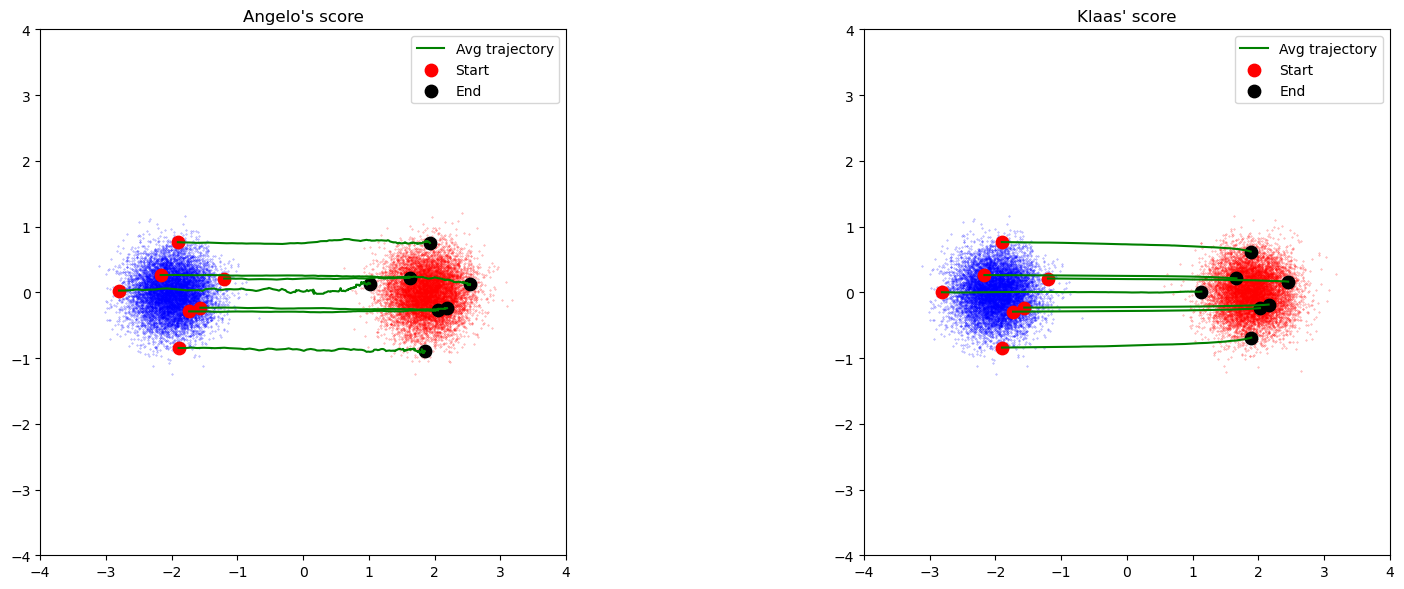

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Trajectory
axes[0].scatter(final_positions1[:10000,0], final_positions1[:10000,1], s=0.1, alpha=0.5, color='red')
axes[0].scatter(initial_positions[:10000,0], initial_positions[:10000:,1], s=0.1, alpha=0.5, color='blue')
for center in range(small_region_centers.shape[0]):
    axes[0].plot(avg_paths1[:, center, 0], avg_paths1[:, center, 1], 'g-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes[0].scatter(avg_paths1[0, center, 0], avg_paths1[0, center, 1], color='red', s=80, label='Start'  if center == 0 else None)
    axes[0].scatter(avg_paths1[-1, center, 0], avg_paths1[-1, center, 1], color='black', s=80, label='End'  if center == 0 else None)
axes[0].set_title("Angelo's score")
axes[0].legend()
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlim(-4., 4.)
axes[0].set_ylim(-4., 4.)

# Trajectory
axes[1].scatter(final_positions2[:10000,0], final_positions2[:10000,1], s=0.1, alpha=0.5, color='red')
axes[1].scatter(initial_positions[:10000,0], initial_positions[:10000:,1], s=0.1, alpha=0.5, color='blue')
for center in range(small_region_centers.shape[0]):
    axes[1].plot(avg_paths2[:, center, 0], avg_paths2[:, center, 1], 'g-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes[1].scatter(avg_paths2[0, center, 0], avg_paths2[0, center, 1], color='red', s=80, label='Start'  if center == 0 else None)
    axes[1].scatter(avg_paths2[-1, center, 0], avg_paths2[-1, center, 1], color='black', s=80, label='End'  if center == 0 else None)
axes[1].set_title("Klaas' score")
axes[1].legend()
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlim(-4., 4.)
axes[1].set_ylim(-4., 4.)


plt.savefig("BasicGaussianTransport.pdf")
plt.tight_layout()
plt.show()

In [13]:
particlesPerCircleNormalized1 = particlesPerCircle1 / particlesPerCircle1[0, :]
particlesPerCircleNormalized2 = particlesPerCircle2 / particlesPerCircle2[0, :]

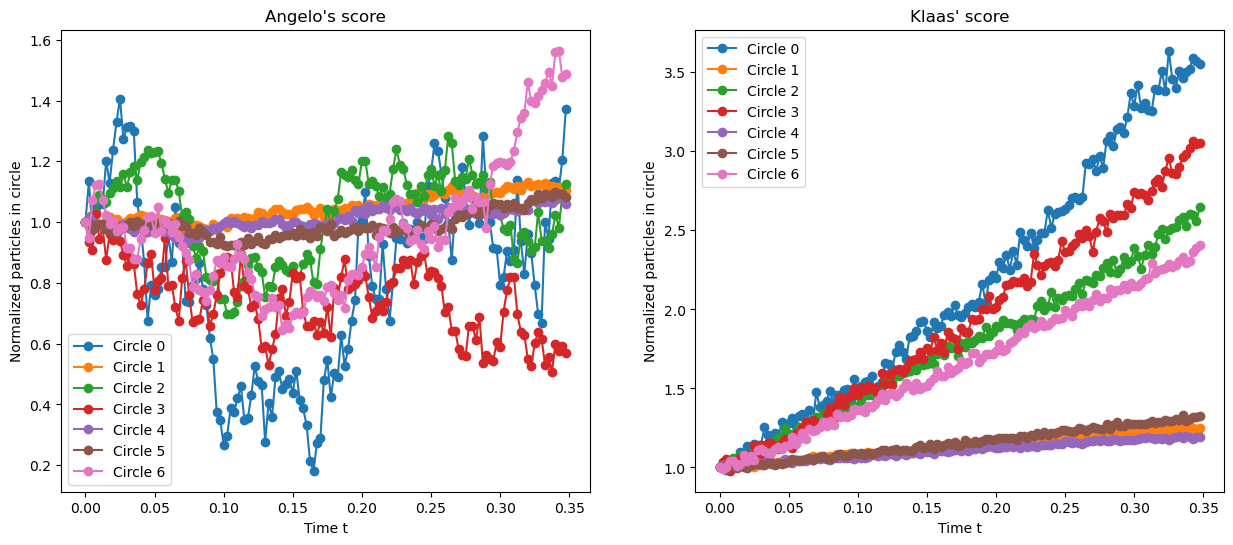

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

timeRange = np.arange(num_steps) * dt

# Trajectory
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 0], 'o-', label='Circle 0')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 1], 'o-', label='Circle 1')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 2], 'o-', label='Circle 2')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 3], 'o-', label='Circle 3')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 4], 'o-', label='Circle 4')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 5], 'o-', label='Circle 5')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 6], 'o-', label='Circle 6')
axes[0].legend()
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Normalized particles in circle')
axes[0].set_title("Angelo's score")

axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 0], 'o-', label='Circle 0')
axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 1], 'o-', label='Circle 1')
axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 2], 'o-', label='Circle 2')
axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 3], 'o-', label='Circle 3')
axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 4], 'o-', label='Circle 4')
axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 5], 'o-', label='Circle 5')
axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 6], 'o-', label='Circle 6')
axes[1].legend()
axes[1].set_xlabel('Time t')
axes[1].set_ylabel('Normalized particles in circle')
axes[1].set_title("Klaas' score")
plt.savefig("massVsTime.pdf")

plt.show()
